In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy.optimize import least_squares
from scipy import optimize
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman
import radvel
from dace_query.spectroscopy import Spectroscopy
import pandas as pd

2026-08-30 09:41:34,315 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ').upper()
split = input_catalog.split(' ')
telescope = split[0]
if telescope == 'TIC':
    author = 'SPOC'
if telescope == 'KIC':
    author = 'Kepler'

filepath = '/Users/joshu/Code/NasaExoplanetArchive_2026.08.23_12.42.57.csv' 
nasa_archive = pd.read_csv(filepath, comment = '#')
nasa_exo = nasa_archive[nasa_archive['tic_id'] == input_catalog]
print(f'Parent Star: {nasa_exo.iloc[0]['hostname']}')
print(f'Distance: {np.round(nasa_exo.iloc[0]['sy_dist']*u.parsec.to(u.lightyear), 2)} ly')

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC') 
    star_Teff = star['Teff'][0]
    star_lumclass = str(star['lumclass'][0]).capitalize()
    if star_Teff >= 33000:
        stellar_class = str(f'O-Type Blue {star_lumclass}')
    elif star_Teff >= 10000:
        stellar_class = str(f'B-Type Blue/White {star_lumclass}')
    elif star_Teff >= 7300:
        stellar_class = str(f'A-Type White {star_lumclass}')
    elif star_Teff >= 6000:
        stellar_class = str(f'F-Type White/Yellow {star_lumclass}')
    elif star_Teff >= 5300:
        stellar_class = str(f'G-Type Yellow {star_lumclass}')
    elif star_Teff >= 3900:
        stellar_class = str(f'K-Type Orange {star_lumclass}')
    elif star_Teff >= 2300:
        stellar_class = str(f'M-Type Red {star_lumclass}')
    else:
        stellar_class = 'Brown Dwarf'  
    print(f'Stellar Class: {stellar_class}')
except:
    print('MAST import error: try again')

RV = False
if nasa_exo['rv_flag'].any() == 1:
    RV = True
print(f'Radial Velocity Available: {RV}')

input catalog:  TIC 307210830


Parent Star: L 98-59
Distance: 34.64 ly
Stellar Class: M-Type Red Dwarf
Radial Velocity Available: True


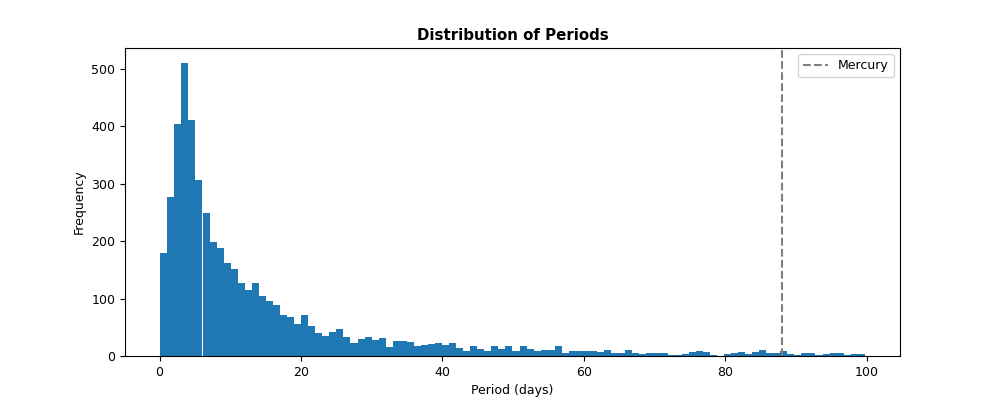

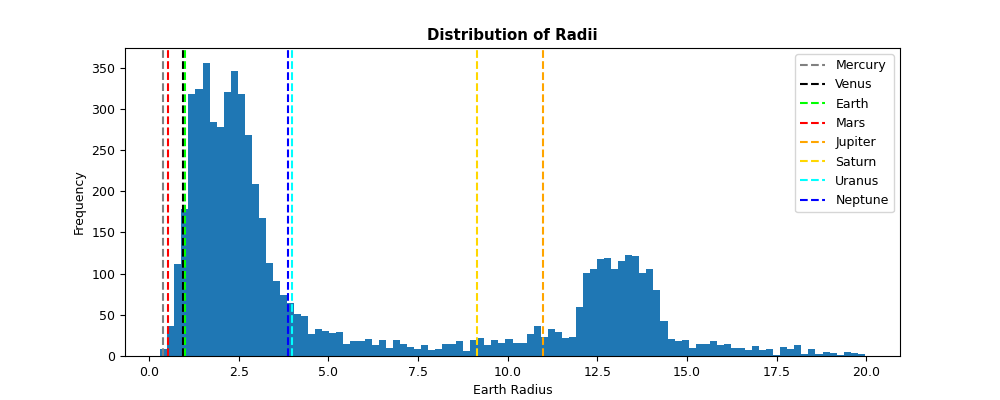

In [4]:
def plot_distributions():
    plt.figure(figsize = (10,4))
    nasa_archive.loc[nasa_archive['pl_orbper'] < 100, 'pl_orbper'].plot.hist(bins = 100, label = '_nolegend_')
    plt.title('Distribution of Periods', fontweight = 'bold')
    plt.xlabel('Period (days)')
    plt.axvline(87.969, color = 'grey', linestyle = '--', label = 'Mercury')
    plt.legend()
    plt.show()
    
    plt.figure(figsize = (10,4))
    nasa_archive.loc[nasa_archive['pl_rade'] < 20, 'pl_rade'].plot.hist(bins = 100, label = '_nolegend_')
    plt.title('Distribution of Radii', fontweight = 'bold')
    plt.xlabel('Earth Radius')
    plt.axvline(0.383, color = 'grey', linestyle = '--', label = 'Mercury')
    plt.axvline(0.95, color = 'black', linestyle = '--', label = 'Venus')
    plt.axvline(1, color = 'lime', linestyle = '--', label = 'Earth')
    plt.axvline(0.53, color = 'red', linestyle = '--', label = 'Mars')
    plt.axvline(10.97, color = 'orange', linestyle = '--', label = 'Jupiter')
    plt.axvline(9.14, color = 'gold', linestyle = '--', label = 'Saturn')
    plt.axvline(3.98, color = 'cyan', linestyle = '--', label = 'Uranus')
    plt.axvline(3.86, color = 'blue', linestyle = '--', label = 'Neptune')
    plt.legend()
    plt.show()

plot_distributions()

### Transit Method

In [5]:
automate_data_cell = True

In [6]:
def import_tess(input_catalog, author, all_data, years):    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:           
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return raw_ts, sectors_list, selected_data

def import_kepler(input_catalog, author, all_data, years):    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:            
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()

        
    print('\nselected data:')
    print(selected_data)
    return raw_ts, quarters_list, selected_data

def limit_range(all_data):
    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
    else:
        year_mask = all_years
    return yr_range, year_mask

all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
print('all data:')
print(all_data)

if automate_data_cell == True:
    years = 0
    automate_data_cell = False
else:
    years_input = input('Year Range: ')
    years_range = years_input.split('-')
    years_min = int(years_range[0])
    years_max = int(years_range[-1])
    if years_min != years_max:
        years = [years_min]
        i = 1
        while years[-1] != years_max:
            years.append(years_min + i)
            i += 1
    
if telescope == 'TIC':
    raw_ts, sectors, selected_data = import_tess(input_catalog, author, all_data, years)
if telescope == 'KIC':
    raw_ts, quarters, selected_data = import_kepler(input_catalog, author, all_data, years)

all data:
SearchResult containing 27 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   307210830      0.0
  1 TESS Sector 05 2018   SPOC     120   307210830      0.0
  2 TESS Sector 08 2019   SPOC     120   307210830      0.0
  3 TESS Sector 09 2019   SPOC     120   307210830      0.0
  4 TESS Sector 10 2019   SPOC     120   307210830      0.0
  5 TESS Sector 11 2019   SPOC     120   307210830      0.0
  6 TESS Sector 12 2019   SPOC     120   307210830      0.0
  7 TESS Sector 28 2020   SPOC     120   307210830      0.0
  8 TESS Sector 29 2020   SPOC     120   307210830      0.0
  9 TESS Sector 32 2020   SPOC     120   307210830      0.0
 10 TESS Sector 39 2021   SPOC     120   307210830      0.0
 11 TESS Sector 37 2021   SPOC     120   307210830      0.0
 12 TESS Sector 38 2021   SPOC     120   307210

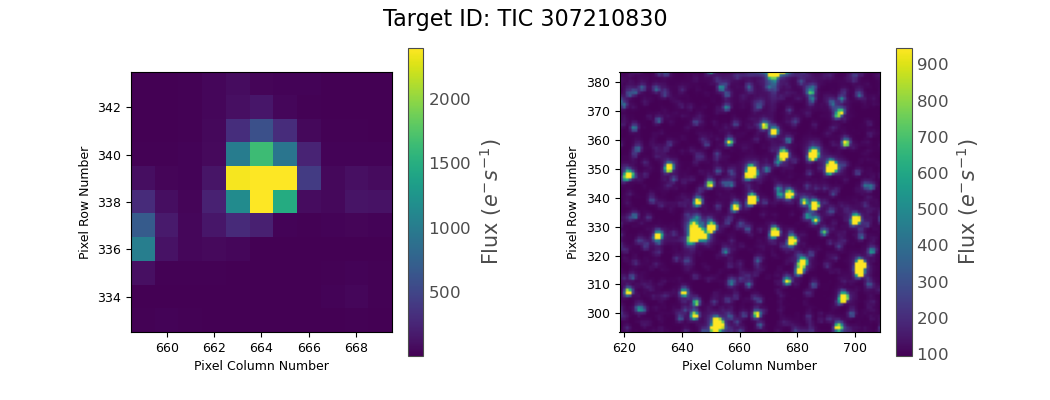

In [7]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 90)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

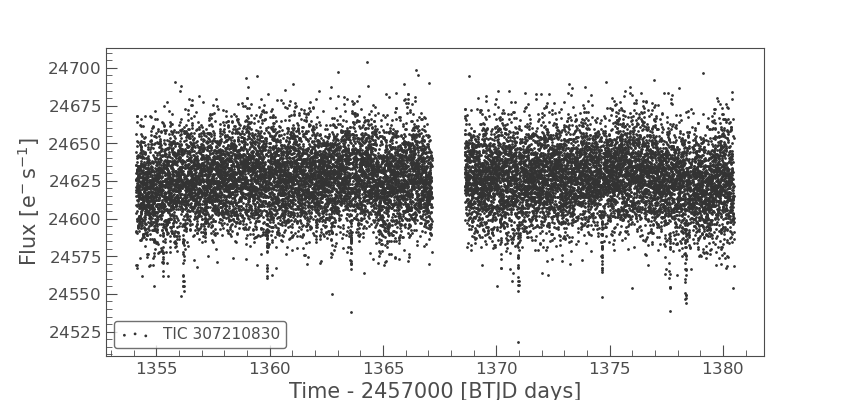

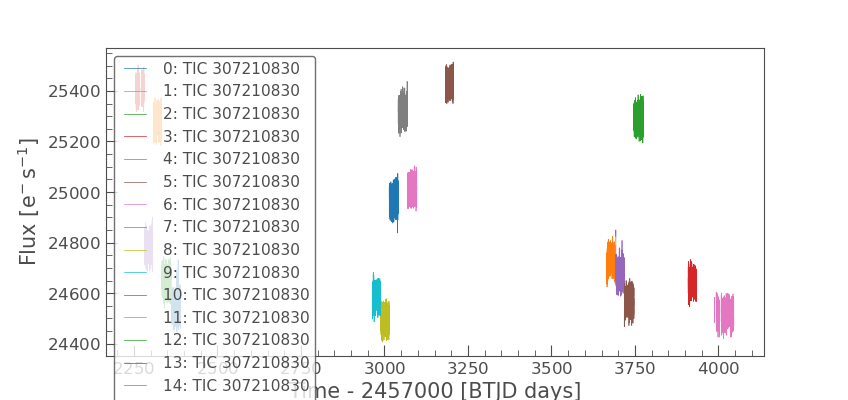

In [8]:
if telescope == 'TIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if telescope == 'KIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if render_plots == True:
    first_ts.scatter()
    raw_ts.plot()

In [9]:
bin_count = 100000
if len(refined_ts) > bin_count:
    bin_width = (np.max(refined_ts.time.value)-np.min(refined_ts.time.value))/(bin_count/.94)
    harmonics_ts = refined_ts.bin(bin_width) 
else:
    harmonics_ts = refined_ts
print(f'Count of points in harmonics test: {len(harmonics_ts)}')

Count of points in harmonics test: 100089


In [10]:
add_period = False

`period` contains 117766 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 138475 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 316110 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 421608 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.
`period` contains 1468642 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Exoplanet Index: 0
Period: 3.6907 d (SNR: 58.905)

Exoplanet Index: 1
Period: 7.4507 d (SNR: 32.2123)

Exoplanet Index: 2
Period: 2.2531 d (SNR: 21.9799)



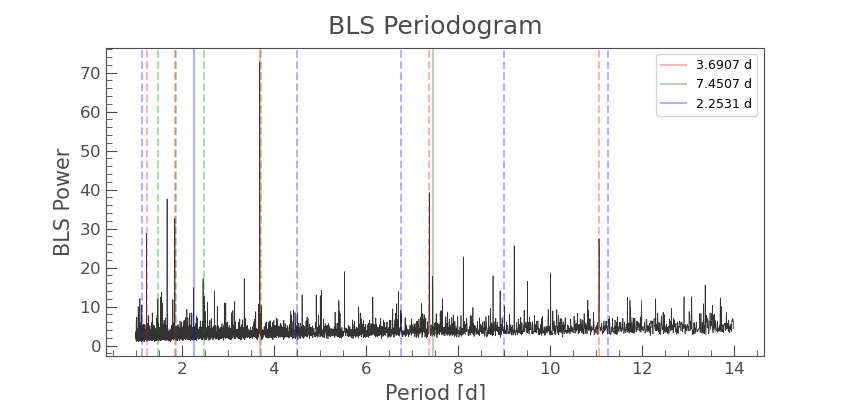

In [11]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    refined_depth = refined_periodogram.depth_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time, refined_depth

def search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    dip_ratio = []
    for each in harmonics:
        folded = harmonics_ts.fold(period = each, epoch_time = refined_time)
        in_transit = np.logical_and((folded.phase.value > -refined_duration.value/3), (folded.phase.value < refined_duration.value/3))
        above_dip = folded.flux.value > 1-refined_depth*(2/3)
        both = np.logical_and(in_transit, above_dip)
        dip_ratio.append(len(folded[both])/len(folded[in_transit]))

        #lim_folded = folded[in_transit]
        #folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        #plt.axhline(1-refined_periodogram.depth_at_max_power*(2/3), color = "green")
        #plt.axvline(-refined_duration.value/3, color = "green")
        #plt.axvline(refined_duration.value/3, color = "green")
        #plt.xlim(-.1,.1)
        #plt.ylim(.9995, 1.0005)
    
    high_freq_h = []
    mean = (dip_ratio[0]+dip_ratio[-1])/2
    
    i = 0
    while i < len(dip_ratio):
        if dip_ratio[i] > mean:
            high_freq_h.append(dip_ratio[i])
        i += 1
    
    transit_index = len(high_freq_h)
    return harmonics, transit_index

def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_depth = final_periodogram.depth_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth

def plot_periodogram(periodogram, selected_periods, min_period, max_period):
    periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

if add_period == False:
    min_period = 1
    max_period = 14
    time_series = [refined_ts]
    cycle = 0
    selected_periods = []
    exoplanets = []
    periods = []
    durations = []
    transit_times = []
    
    while True:
        initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
        if cycle == 0:
            first_periodogram = initial_periodogram
        cycle += 1
    
        refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
        if np.max(refined_periodogram.snr) < 10:
            break

        harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
        for each in harmonics:
            if each == harmonics[transit_index]:
                selected_periods.append(each)
        
        final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
        exoplanets.append({
            'stellar_class': stellar_class,
            'period': final_period, 
            'duration': final_duration, 
            'transit_t0': final_time,       
            'depth': final_depth,
            'snr': np.max(final_periodogram.snr)
        }) 
        periods.append(final_period.value)
        durations.append(final_duration.value)
        transit_times.append(final_time.value)
    add_period = True
else:
    refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
    harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
    for each in harmonics:
        if each == harmonics[transit_index]:
            selected_periods.append(each)
    final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({
        'stellar_class': stellar_class,
        'period': final_period, 
        'duration': final_duration, 
        'transit_t0': final_time,       
        'depth': final_depth,
        'snr': np.max(final_periodogram.snr)
    }) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)  

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    print(f'Period: {round(each["period"],4)} (SNR: {round(each["snr"],4)})')
    print()
plot_periodogram(first_periodogram, selected_periods, min_period, max_period)

In [12]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)
    period = period.to(u.s)
    semimajor_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    semimajor_axis = semimajor_axis.to(u.au)
    print(f'Semimajor Axis: {round(semimajor_axis, 4)}') 
    return semimajor_axis

def equilibrium_temperature(star, semimajor_axis):
    star_rad = star['rad'][0]*u.Rsun.to(u.m)*u.m
    star_temp = star_Teff*u.k
    sm_axis_m = semimajor_axis.to(u.m)
    equilibrium_temp = star_temp * ((star_rad/(2*sm_axis_m))**(1/2)) * (1**(1/4))
    print(f'Equilibrium Temperature: {round(equilibrium_temp, 4)}')
    return equilibrium_temp

def habitable_zone(star, semimajor_axis):
    star_luminosity = star['lum'][0]*u.L_sun
    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if semimajor_axis < inner_lim:
        habitability = 'too hot'
    elif semimajor_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    print(f'Habitability: {habitability}')
    return habitability

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    semimajor_axis = orbital_distance(star, each['period'])
    each['semimajor_axis'] = semimajor_axis

    equilibrium_temp = equilibrium_temperature(star, each['semimajor_axis'])
    each['equilibrium_temp'] = equilibrium_temp

    habitability = habitable_zone(star, each['semimajor_axis'])
    each['habitability'] = habitability
    print()

Exoplanet Index: 0
Semimajor Axis: 0.031 AU
Equilibrium Temperature: 526.0612 k
Habitability: too hot

Exoplanet Index: 1
Semimajor Axis: 0.0496 AU
Equilibrium Temperature: 416.2355 k
Habitability: too hot

Exoplanet Index: 2
Semimajor Axis: 0.0223 AU
Equilibrium Temperature: 620.1239 k
Habitability: too hot



In [13]:
remove_lc = False

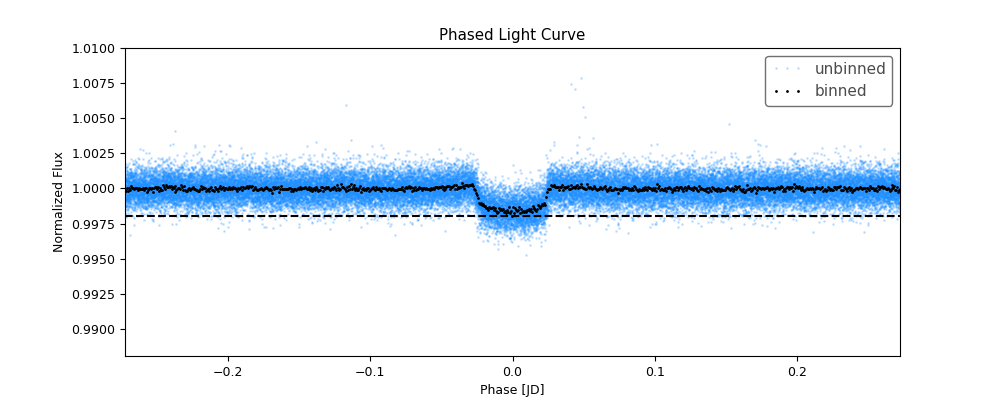

Exoplanet Index: 0
1.5053 earthRad
0.1343 jupiterRad


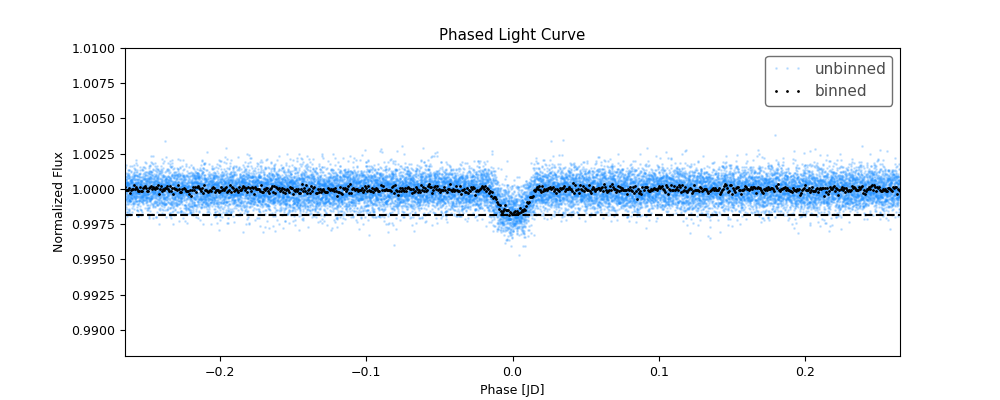

Exoplanet Index: 1
1.4743 earthRad
0.1315 jupiterRad


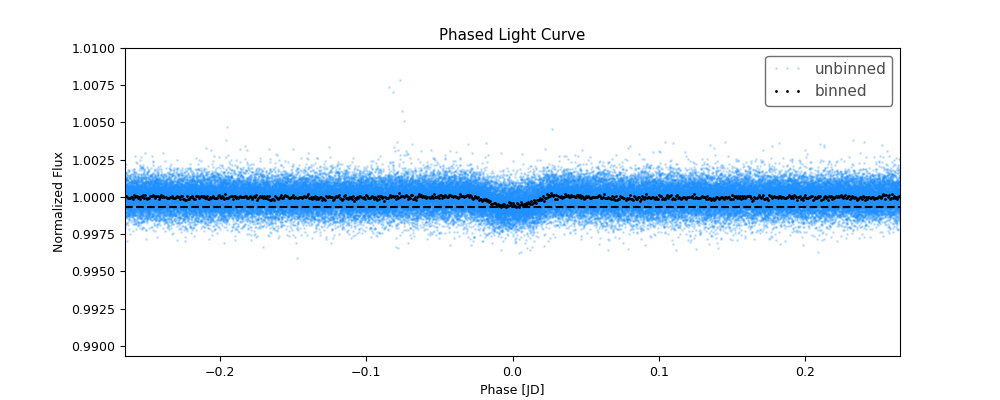

Exoplanet Index: 2
0.8887 earthRad
0.0793 jupiterRad


In [14]:
def clean_data(mission, refined_ts):
    transit_mask = refined_ts.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        clean_ts = raw_ts.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        clean_ts = first_ts.remove_nans().flatten(mask = transit_mask)
    return clean_ts

def plot_light_curve(clean_ts, period, t0, duration):
    phased_lc = clean_ts.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(1/60/24)
    dip = binned_lc.flux.value.min()
    depth = 1 - dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc, phased_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

def run_lc_loop(exoplanets, clean_ts):
    for each in exoplanets:
        depth, binned_lc, phased_lc = plot_light_curve(clean_ts, each["period"], each["transit_t0"], each["duration"])
        each["depth"] = depth
    
        transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
        each["light_curve"] = binned_lc[transit_event]

        print(f'Exoplanet Index: {exoplanets.index(each)}')
        radius = estimate_radius(star, depth)
        each["radius"] = radius

if remove_lc == False:
    if telescope == "TIC":
        clean_ts = clean_data(sectors, refined_ts)
    if telescope == "KIC":
        clean_ts = clean_data(quarters, refined_ts)
        
    run_lc_loop(exoplanets, clean_ts)
    remove_lc = True
else:
    remove_index = int(input('Remove Candidate(s)?'))
    del exoplanets[remove_index]
    run_lc_loop(exoplanets, clean_ts)

Exoplanet Index: 0
Radius: 1.2981 earthRad
Inclination: 88.5945 deg
Eccentricity: 0.0
Argument of Periapsis (ω): 90.0 deg


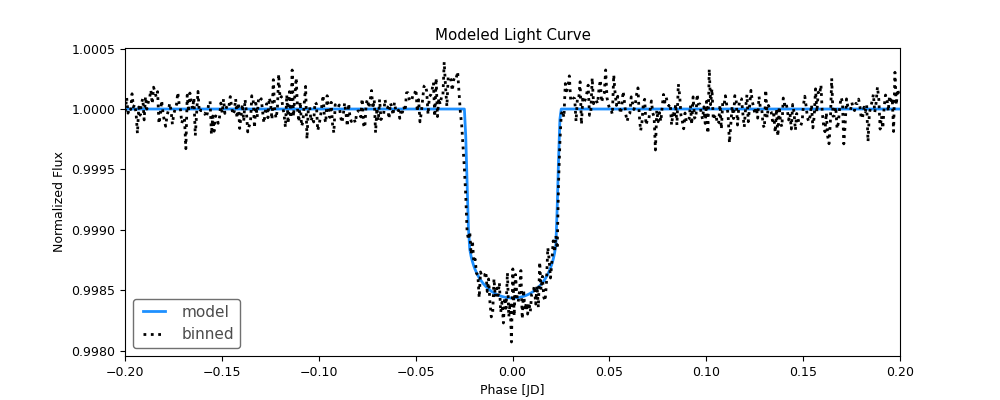

Exoplanet Index: 1
Radius: 1.5069 earthRad
Inclination: 88.4145 deg
Eccentricity: 0.0
Argument of Periapsis (ω): 92.2792 deg


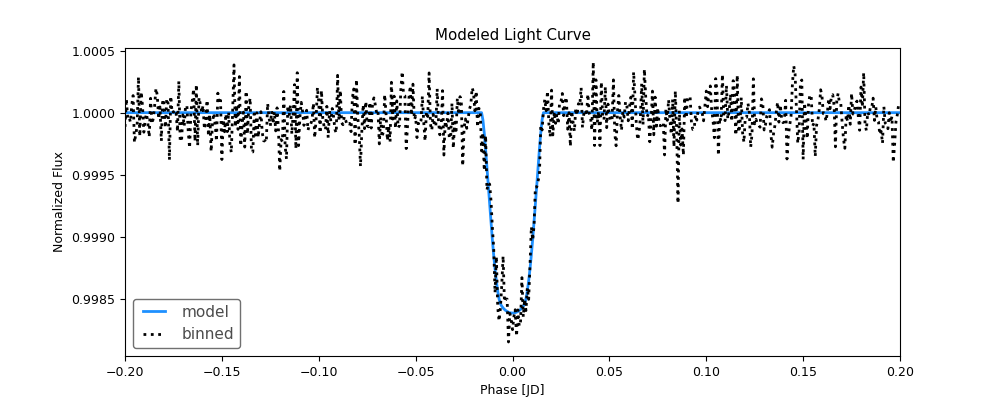

Exoplanet Index: 2
Radius: 0.752 earthRad
Inclination: 87.518 deg
Eccentricity: 0.0
Argument of Periapsis (ω): 98.8784 deg


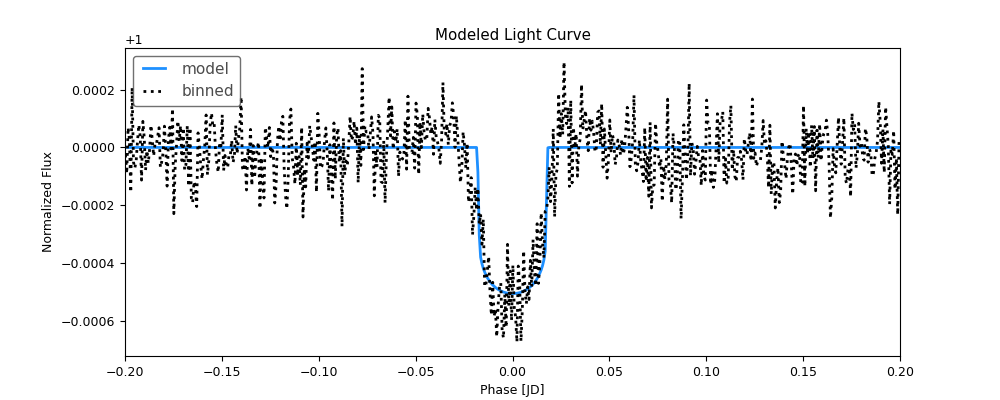

In [15]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['semimajor_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'binned')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'Radius: {round(each['radius'],4)}')
    print(f'Inclination: {round(each['inclination'],4)}')
    print(f'Eccentricity: {round(each['eccentricity'],4)}')
    print(f'Argument of Periapsis (ω): {round(each['arg_periapsis'],4)}')

    plot_model(each, star)
    each.pop('light_curve')

In [16]:
for each in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(each)}')
    b1 = ((each['semimajor_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'Impact Parameter: {round(each['impact_parameter'],4)}')
    print()

Exoplanet Index: 0
Impact Parameter: 0.5211

Exoplanet Index: 1
Impact Parameter: 0.9389

Exoplanet Index: 2
Impact Parameter: 0.6621



### Radial Velocity Method

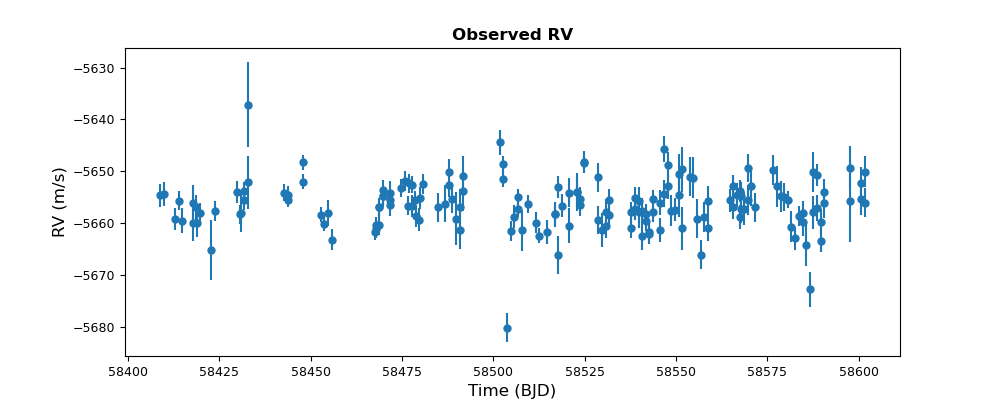

In [17]:
if RV == True:
    def plot_rv(rv_time, rv, rv_err):
        fig, ax = plt.subplots(figsize = (10,4))
        ax.errorbar(rv_time, rv, rv_err, fmt= 'o')
        ax.set_xlabel('Time (BJD)', fontsize = 12)
        ax.set_ylabel('RV (m/s)', fontsize = 12)
    
    def import_harps():
        try:
            rv_ts = Spectroscopy.get_timeseries(input_catalog, sorted_by_instrument = True)
        except:
            print('DACE import error: try again')
            
        index = []
        for each in rv_ts.keys():
            if each.find('HARPS15') != -1:
                index.append(each)
            elif each.find('HARPS') != -1:
                index.append(each)
        index0 = index[0]
        index1 = list(rv_ts[index0])[0]
        index2 = list(rv_ts[index0][index1])[0]
        rv_data = rv_ts[index0][index1][index2]
        rv_time, rv, rv_err = rv_data['rjd'], rv_data['rv'], rv_data['rv_err'] 
    
        if render_plots == True:
            plot_rv(rv_time, rv, rv_err)
            plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
        
        rv_norm = (rv - np.median(rv))    
        sigma2 = 2*np.std(rv_norm)    
        
        i = 0 
        while i < len(rv_norm):
            if (rv_norm[i] > sigma2) or (rv_norm[i] < -sigma2):
                rv_time = np.delete(rv_time, i)
                rv = np.delete(rv, i)
                rv_err = np.delete(rv_err, i)
            i += 1
        return input_catalog, rv_time, rv, rv_err
    
    input_catalog, rv_time, rv, rv_err = import_harps()

parameter                     value      vary
per1                        3.69068      False
tc1                         2256.73       True
secosw1                           0      False
sesinw1                           0      False
logk1                       1.51801       True
per2                        7.45071      False
tc2                         2256.83       True
secosw2                           0      False
sesinw2                           0      False
logk2                       1.51801       True
per3                        2.25309      False
tc3                         2256.16       True
secosw3                           0      False
sesinw3                           0      False
logk3                       1.51801       True
gamma                             0      False
jit                               0       True
tp1                          2255.8           
e1                                0           
w1                                0           
k1            

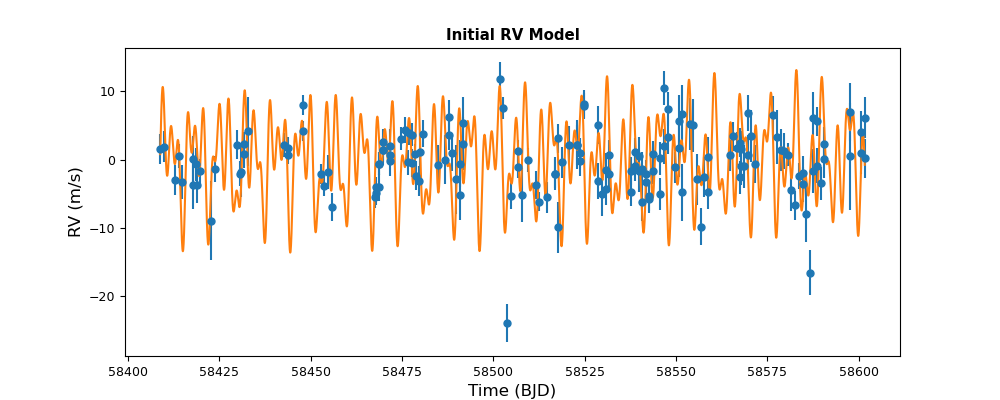

In [18]:
if RV == True:
    def initialize_model():
        time_base = int(np.mean(rv_time))
        params = radvel.Parameters(len(exoplanets), basis = 'per tc secosw sesinw logk')
        i = 0
        while i < len(exoplanets):
            params[f'per{i+1}'] = radvel.Parameter(value = exoplanets[i]['period'].value)
            params[f'tc{i+1}'] = radvel.Parameter(value = exoplanets[i]['transit_t0'].value)
            params[f'secosw{i+1}'] = radvel.Parameter(value = 0)
            params[f'sesinw{i+1}'] = radvel.Parameter(value = 0)
            params[f'logk{i+1}'] = radvel.Parameter(value = np.log(np.std(rv)))
            i += 1
        radvel_model = radvel.RVModel(params, time_base = time_base)
        like = radvel.likelihood.RVLikelihood(radvel_model, rv_time, rv, rv_err)
        like.params['gamma'] = radvel.Parameter(value = np.median(rv), vary = False, linear = True)
        like.params['jit'] = radvel.Parameter(value = 1)
        i = 0
        while i < len(exoplanets):
            like.params[f'per{i+1}'].vary = False
            like.params[f'tc{i+1}'].vary = True
            like.params[f'secosw{i+1}'].vary = False
            like.params[f'sesinw{i+1}'].vary = False
            like.params[f'logk{i+1}'].vary = True
            i += 1
        print(like)
        plot_rv(rv_time, rv-np.median(rv), rv_err)
        model_time = np.linspace(np.min(rv_time), np.max(rv_time), 10000)
        plt.plot(model_time, like.model(model_time))
        plt.title('Initial RV Model', fontweight = 'bold')
        return radvel_model, like
    
    radvel_model, like = initialize_model()

parameter                     value      vary
per1                        3.69068      False
tc1                         2257.72       True
secosw1                           0      False
sesinw1                           0      False
logk1                      0.777946       True
per2                        7.45071      False
tc2                         2257.99       True
secosw2                           0      False
sesinw2                           0      False
logk2                      0.178332       True
per3                        2.25309      False
tc3                         2256.58       True
secosw3                           0      False
sesinw3                           0      False
logk3                     -0.962517       True
gamma                      -5656.66      False
jit                         3.05619       True
tp1                         2256.79           
e1                                0           
w1                                0           
k1            

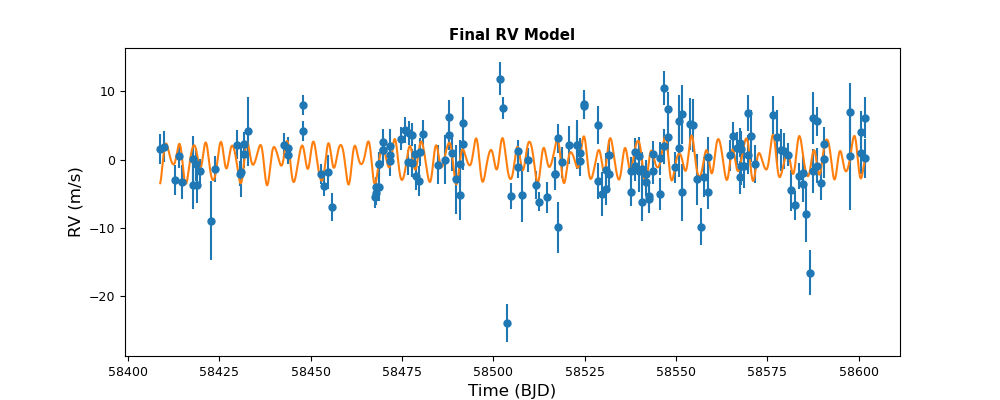

In [19]:
if RV == True:
    def run_rvmodel():
        posterior = radvel.posterior.Posterior(like)
        results = optimize.minimize(posterior.neglogprob_array, posterior.get_vary_params(), method = 'Powell')
        derived_params = like.params.basis.to_synth(like.params)
        print(posterior)
        plot_rv(rv_time, rv-np.median(rv), rv_err)
        model_time = np.linspace(np.min(rv_time), np.max(rv_time), 10000)
        plt.plot(model_time, like.model(model_time))
        plt.title('Final RV Model', fontweight = 'bold')
    
    run_rvmodel()
    i = 0
    derived_params = like.params.basis.to_synth(like.params)
    while i < len(exoplanets):
        exoplanets[i]['k'] = derived_params[f'k{i+1}'].value
        exoplanets[i]['semiamplitude']= derived_params[f'k{i+1}'].value*u.m/u.s
        i += 1

In [20]:
if RV == True:    
    def calc_mass(k, period, inclination):
        m1 = (period*u.day.to(u.s)*u.s)/(2*np.pi*const.G)
        m2 = k*u.m/u.s
        m3 = star['mass'][0]*u.M_sun.to(u.kg)*u.kg
        m4 = 1    #1-(eccentricity**2)
        d1 = np.sin(np.deg2rad(inclination))
        mass = ((m1**(1/3)) * m2 * (m3**(2/3)) * (m4**(1/2)))/d1
        mass_E = mass.to(u.Mearth)
        mass_J = mass.to(u.Mjupiter)
    
        if mass_E < 2*u.Mearth:
            exo_class = 'Terrestrial'
        elif mass_E < 10*u.Mearth:
            exo_class = 'Super-Earth'
        elif mass_E < 15*u.Mearth:
            exo_class = 'Sub-Neptune'
        elif mass_E < 150*u.Mearth:
            exo_class = 'Neptunian'
        elif mass_J < 13*u.Mjupiter:
            exo_class = 'Jovian'
        else:
            exo_class = 'Brown Dwarf'
        
        print(f'Mass: {round(mass_E, 4)}')
        print(f'Mass: {round(mass_J, 4)}')
        print(f'Class: {exo_class}')
        return mass_E, mass_J, exo_class
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        mass_E, mass_J, exo_class = calc_mass(each['k'], each['period'].value, each['inclination'].value)
        each['mass_E'], each['mass_J'], each['exo_class'] = mass_E, mass_J, exo_class
        print()

Exoplanet Index: 0
Mass: 2.3207 earthMass
Mass: 0.0073 jupiterMass
Class: Super-Earth

Exoplanet Index: 1
Mass: 1.6104 earthMass
Mass: 0.0051 jupiterMass
Class: Terrestrial

Exoplanet Index: 2
Mass: 0.3456 earthMass
Mass: 0.0011 jupiterMass
Class: Terrestrial



In [21]:
if RV == True:
    def calc_bulk_density(mass, radius):
        volume = (4/3)*np.pi*((radius.to(u.cm))**3)
        mass_g = mass.to(u.g)
        bulk_density = mass_g/volume
        if bulk_density.value < 3:    
            composition = 'Ice/Gas' 
        elif bulk_density.value < 20:    
            composition = 'Iron/Rock'
        else:   
            composition = 'Degenerate'
            
        print(f'Bulk Density: {round(bulk_density, 4)}')
        print(f'Composition: {composition}')
        return bulk_density, composition
    
    def calc_surf_grav(mass, radius):
        mass_kg = mass.to(u.kg)
        radius_m = radius.to(u.m)
        surf_grav = (const.G*mass_kg)/(radius_m**2)
        print(f'Surface Gravity: {round(surf_grav, 4)}')
        return surf_grav
    
    for each in exoplanets:
        print(f'Exoplanet Index: {exoplanets.index(each)}')
        bulk_density, composition = calc_bulk_density(each['mass_E'], each['radius'])
        each['bulk_density'] = bulk_density
        each['composition'] = composition
        
        surf_grav = calc_surf_grav(each['mass_E'], each['radius'])
        each['surf_grav'] = surf_grav
        print()

Exoplanet Index: 0
Bulk Density: 5.8304 g / cm3
Composition: Iron/Rock
Surface Gravity: 13.4953 m / s2

Exoplanet Index: 1
Bulk Density: 2.586 g / cm3
Composition: Ice/Gas
Surface Gravity: 6.9489 m / s2

Exoplanet Index: 2
Bulk Density: 4.4655 g / cm3
Composition: Iron/Rock
Surface Gravity: 5.988 m / s2



### Results & Comparison

In [22]:
for exoplanet in exoplanets:
    print(f'Exoplanet Index: {exoplanets.index(exoplanet)}')
    for each in exoplanet:
        try:
            if type(exoplanet[each]) == str:
                print(f'{each}: {exoplanet[each]}')
            else:
                print(f'{each}: {round(exoplanet[each], 2)}')
        except:
            print(f'{each}: {round(float(exoplanet[each].value), 2)}')

    match = nasa_exo[round(nasa_exo['pl_orbper']) == round(exoplanet['period'])]
    radius_accuracy = round((1-np.abs(match['pl_rade']-exoplanet['radius'])/match['pl_rade'])*100, 2)
    print(f'Radius Accuracy: {radius_accuracy.to_numpy()}%')
    mass_accuracy = round((1-np.abs(match['pl_bmasse']-exoplanet['mass_E'])/match['pl_bmasse'])*100, 2)
    print(f'Mass Accuracy: {mass_accuracy.to_numpy()}%')
    print()

Exoplanet Index: 0
stellar_class: M-Type Red Dwarf
period: 3.69 d
duration: 0.04 d
transit_t0: 2256.73
depth: 0.0
snr: 58.91
semimajor_axis: 0.03 AU
equilibrium_temp: 526.06 k
habitability: too hot
radius: 1.3 earthRad
inclination: 88.59 deg
eccentricity: 0.0
arg_periapsis: 90.0 deg
impact_parameter: 0.52
k: 2.18
semiamplitude: 2.18 m / s
mass_E: 2.32 earthMass
mass_J: 0.01 jupiterMass
exo_class: Super-Earth
bulk_density: 5.83 g / cm3
composition: Iron/Rock
surf_grav: 13.5 m / s2
Radius Accuracy: [97.67]%
Mass Accuracy: [83.96]%

Exoplanet Index: 1
stellar_class: M-Type Red Dwarf
period: 7.45 d
duration: 0.03 d
transit_t0: 2256.83
depth: 0.0
snr: 32.21
semimajor_axis: 0.05 AU
equilibrium_temp: 416.24 k
habitability: too hot
radius: 1.51 earthRad
inclination: 88.41 deg
eccentricity: 0.0
arg_periapsis: 92.28 deg
impact_parameter: 0.94
k: 1.2
semiamplitude: 1.2 m / s
mass_E: 1.61 earthMass
mass_J: 0.01 jupiterMass
exo_class: Terrestrial
bulk_density: 2.59 g / cm3
composition: Ice/Gas
surf

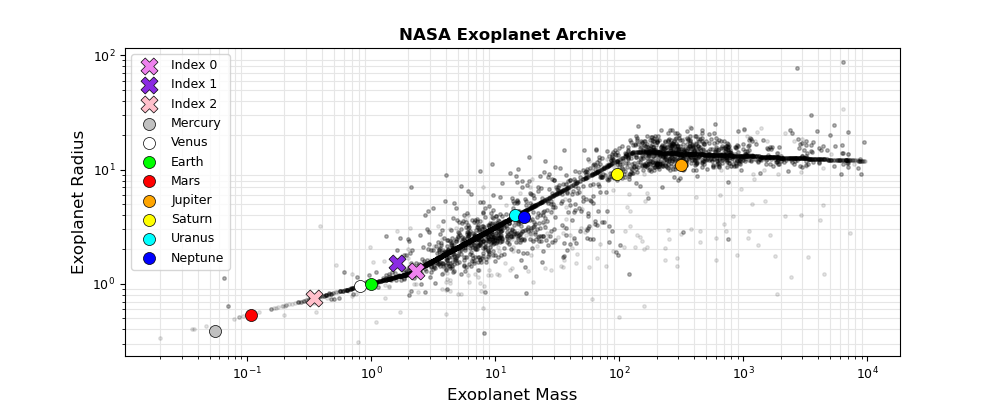

In [23]:
if RV == True and render_plots == True:
    def plot_archive(exoplanet):
        fig, ax = plt.subplots(figsize = (10, 4))
        refined_constraints = np.logical_and(
            (nasa_archive['pl_radeerr1']/nasa_archive['pl_rade']) < 1,
            (nasa_archive['pl_bmasseerr1']/nasa_archive['pl_bmasse']) < 1
        )
        refined_archive = nasa_archive[refined_constraints]
        ax.loglog(nasa_archive['pl_bmasse'], nasa_archive['pl_rade'], '.', color = 'black', alpha = .1, zorder = 2)
        ax.loglog(refined_archive['pl_bmasse'], refined_archive['pl_rade'], '.', color = 'black', alpha = .2, zorder = 2)
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Exoplanet Mass', fontsize = 12)
        ax.set_ylabel('Exoplanet Radius', fontsize = 12)
        ax.set_title('NASA Exoplanet Archive', fontsize = 12, fontweight = 'bold')
        ax.grid(which = 'minor', color = '.9', zorder = 1)
        ax.set_xlabel('Exoplanet Mass', fontsize = 12)
        ax.set_ylabel('Exoplanet Radius', fontsize = 12)
        ax.set_title('NASA Exoplanet Archive', fontsize = 12, fontweight = 'bold')

        for each in exoplanets:
            if exoplanets.index(each) == 0:
                color = 'violet'
            if exoplanets.index(each) == 1:
                color = 'blueviolet'
            if exoplanets.index(each) == 2:
                color = 'pink'
            if exoplanets.index(each) == 3:
                color = 'fuchsia'
            if exoplanets.index(each) == 4:
                color = 'hotpink'
            
            ax.scatter(
                each['mass_E'].value, 
                each['radius'].value, 
                s = 150, 
                color = color, 
                marker = 'X', 
                edgecolor = 'black', 
                linewidth = .5, 
                label = (f'Index {exoplanets.index(each)}'), 
                zorder = 4
            )
        
        ax.scatter(0.0553, 0.383, s = 300, marker = '.', color = 'silver', label = 'Mercury', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.815, 0.95, s = 300, marker = '.', color = 'white', label = 'Venus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(1, 1, s = 300, marker = '.', color = 'lime', label = 'Earth', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(0.107, 0.53, s = 300, marker = '.', color = 'red', label = 'Mars', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(317.8, 10.97, s = 300, marker = '.', color = 'orange', label = 'Jupiter', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(95.2, 9.14, s = 300, marker = '.', color = 'yellow', label = 'Saturn', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(14.5, 3.98, s = 300, marker = '.', color = 'cyan', label = 'Uranus', edgecolor = 'black', linewidths = .5, zorder = 3)
        ax.scatter(17.1, 3.86, s = 300, marker = '.', color = 'blue', label = 'Neptune', edgecolor = 'black', linewidths = .5, zorder = 3)
        plt.legend()
        
    plot_archive(exoplanets)

#### Ideas for improvement
- merge transit & rv model
- add uncertainty margins (markov chain monte carlo)
- test loop comparing accuracy
- output results to external storage/spreadsheet
- import archive API instead of downloaded file
- test false positives
- imporove detection for longer periods
- transit timing variations
- atmospheric spectroscopy
- demonstrate doppler shift
- astrometry method